# Used Car Listings — Price Prediction Model (Phase 3)

Phases 1 and 2 looked at one factor at a time: mileage's correlation with price on its own, year on its own, title status on its own. A model combines mileage, year, title status, and brand together, and can say how much each one is worth **while holding the others constant** — which is the one thing a correlation coefficient or a group-by average can't do.

This is a first pass, not a finished product: a simple, honest baseline plus an equally honest look at its limits.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/processed/us_cars_clean.csv')
df.shape

(2448, 10)

## 1. Turning the raw columns into model inputs

Three things need handling before any model can use this data:

- **`brand` has 28 categories, several with only 1–2 listings.** A model can't learn a reliable effect for a brand it's seen once, so brands with fewer than 15 listings — the same threshold used for the phase 2 SQL queries — get grouped into `other`.
- **`title_status` is text** (`"clean vehicle"` / `"salvage insurance"`); models need numbers, so it becomes a 0/1 column, `is_salvage`.
- **Categories need one-hot encoding** — turning `brand_grp` into a separate 0/1 column per brand — and one category has to be dropped as the reference point (`drop_first=True`), or the columns would be redundant with each other.

In [2]:
brand_counts = df['brand'].value_counts()
common_brands = brand_counts[brand_counts >= 15].index
df['brand_grp'] = df['brand'].where(df['brand'].isin(common_brands), 'other')
df['is_salvage'] = (df['title_status'] == 'salvage insurance').astype(int)

print("Brand groups used:", sorted(df['brand_grp'].unique()))

X = pd.get_dummies(df[['mileage', 'year', 'is_salvage', 'brand_grp']], columns=['brand_grp'], drop_first=True)
y = df['price']
print("\nFeature matrix:", X.shape)
X.head()

Brand groups used: ['bmw', 'chevrolet', 'chrysler', 'dodge', 'ford', 'gmc', 'hyundai', 'jeep', 'nissan', 'other']

Feature matrix: (2448, 12)


,mileage,year,is_salvage,brand_grp_chevrolet,brand_grp_chrysler,brand_grp_dodge,brand_grp_ford,brand_grp_gmc,brand_grp_hyundai,brand_grp_jeep,brand_grp_nissan,brand_grp_other
0,274117,2008,0,False,False,False,False,False,False,False,False,True
1,190552,2011,0,False,False,False,True,False,False,False,False,False
2,39590,2018,0,False,False,True,False,False,False,False,False,False
3,64146,2014,0,False,False,False,True,False,False,False,False,False
4,6654,2018,0,True,False,False,False,False,False,False,False,False


## 2. Splitting into train and test

The model only ever learns from the training set. The test set is held back so evaluation reflects how it performs on listings it's never seen — the honest version of checking whether this actually works, not just whether it memorized the training data.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {len(X_train)} listings  |  Test: {len(X_test)} listings")

Train: 1958 listings  |  Test: 490 listings


## 3. Baseline: linear regression

Every X → price relationship here is a straight line, weighted by a coefficient. That's what makes it the right first model to try: it's easy to fit, and every coefficient is directly interpretable as "dollars per unit."

**R² and MAE, in plain terms:** R² is the share of price variation the model explains (1.0 would be perfect, 0 would be no better than always guessing the average). MAE is the average dollar amount the prediction is off by, in the same units as price, which is easier to feel than R² alone.

In [4]:
lr = LinearRegression().fit(X_train, y_train)
pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
print(f"R²:  {r2_lr:.3f}")
print(f"MAE: ${mae_lr:,.0f}")

R²:  0.304
MAE: $7,244


## 4. What the coefficients actually say

In [5]:
coef = pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False)
print("Per-mile:      $%.3f  (so 10,000 miles ≈ $%.0f)" % (coef['mileage'], coef['mileage']*10000))
print("Per model year: $%.0f" % coef['year'])
print("Salvage title:  $%.0f (holding mileage, year, and brand constant)" % coef['is_salvage'])

Per-mile:      $-0.085  (so 10,000 miles ≈ $-850)
Per model year: $564
Salvage title:  $-6994 (holding mileage, year, and brand constant)


**This is the most interesting number in the whole project so far.** Phase 1 found clean-title listings averaging about \$16,700 more than salvage ones, raw. Controlling for mileage, year, and brand at the same time, the *isolated* salvage effect drops to around \$7,000. The rest of that raw \$16,700 gap wasn't really about the title status alone — salvage listings in this data also skew toward higher mileage and different brands, and the raw comparison was bundling all of that together. This is exactly what "holding other factors constant" buys you, and exactly the kind of thing a plain group-by average can't separate out.

## 5. A second model: random forest

In [6]:
rf = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42).fit(X_train, y_train)
pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, pred_rf)
mae_rf = mean_absolute_error(y_test, pred_rf)
print(f"R²:  {r2_rf:.3f}")
print(f"MAE: ${mae_rf:,.0f}")
print(f"\n(linear regression was R² {r2_lr:.3f}, MAE ${mae_lr:,.0f})")

R²:  0.337
MAE: $7,030

(linear regression was R² 0.304, MAE $7,244)


A random forest can pick up patterns a straight line can't — like mileage mattering more for older cars than newer ones — which is why it edges out the linear model on both metrics here. The trade-off: there's no single "$ per mile" number to point to anymore. What it offers instead is *feature importance* — not a dollar effect, but a relative measure of how much each feature helped the model make accurate splits.

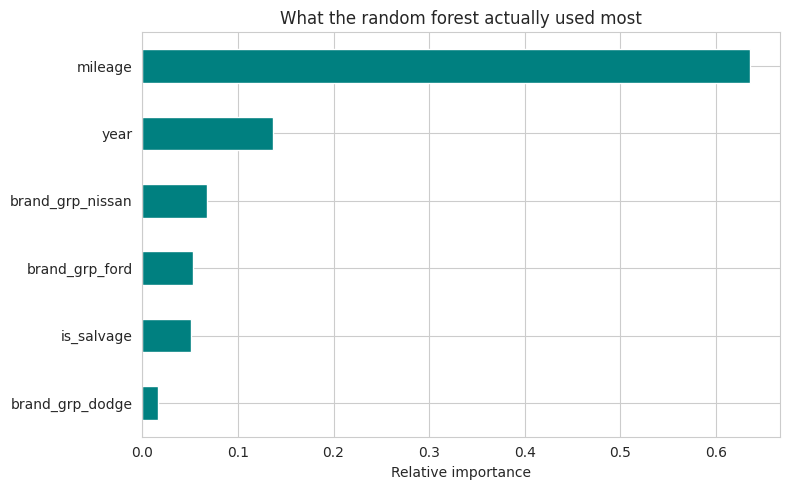

In [7]:
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(6)

fig, ax = plt.subplots()
importance.sort_values().plot(kind='barh', ax=ax, color='teal')
ax.set_xlabel('Relative importance')
ax.set_title('What the random forest actually used most')
plt.tight_layout()
plt.show()

Mileage dominates by a wide margin here — worth noting this is a *different* ranking than the coefficients above, because importance measures how useful a feature was for splitting the data, not how many dollars it's worth. The two models agree on the story (mileage and year matter most, salvage status matters too) but answer different questions.

## 6. Where the model is right, and where it's wrong

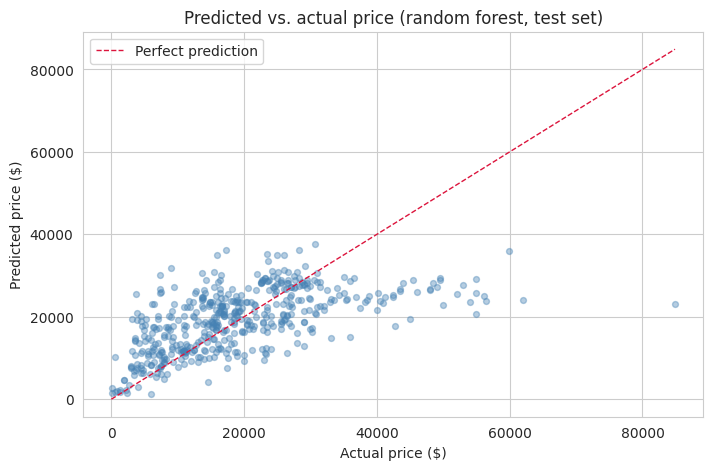

In [8]:
fig, ax = plt.subplots()
ax.scatter(y_test, pred_rf, alpha=0.4, s=18, color='steelblue')
lims = [0, max(y_test.max(), pred_rf.max())]
ax.plot(lims, lims, color='crimson', linestyle='--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual price ($)')
ax.set_ylabel('Predicted price ($)')
ax.set_title('Predicted vs. actual price (random forest, test set)')
ax.legend()
plt.show()

Points on the dashed line would be perfect predictions. The real pattern: the model does reasonably well in the middle of the price range and gets noticeably worse at the high end, where expensive listings often get under-predicted — there just aren't many $50k+ listings to learn that part of the pattern from.

## 7. Being honest about R² ≈ 0.3

Neither model explains more than about a third of the variation in price. That's not a bug to fix quietly — it's a real, useful finding about what this dataset can and can't do. The likely reasons:

- **Real price drivers aren't in the data.** Trim level, options, exact condition beyond "clean vs. salvage," accident history detail, and how the listing itself was written all affect what a car sells for, and none of them are columns here.
- **This is auction data, not retail pricing.** Auction prices carry more noise than a dealership sticker price — reserve prices, bidder turnout on a given day, and auction-specific dynamics add variation that mileage/year/brand/title status can't capture.
- **~2,450 rows is enough to explore, not enough to fully trust.** Some brand groups have thin representation even after collapsing rare ones into `other`.

### What I'd try next
- Add `region` (already built in phase 2's database) as a feature
- Try gradient boosting (XGBoost / LightGBM) instead of a random forest
- Cross-validation instead of a single train/test split, to see how much these numbers move around
- An interaction term for mileage × year, since a 100,000-mile 2005 car and a 100,000-mile 2019 car likely aren't discounted the same way

## Key takeaways

- Controlling for mileage, year, and brand at once cuts the "salvage title" price effect roughly in half versus the raw comparison — evidence that part of phase 1's headline finding was partly confounded with other factors, not purely about title status.
- A random forest edges out linear regression on both R² and MAE, at the cost of losing simple dollar-per-unit coefficients — the real trade-off between explainability and raw accuracy, not a strictly better-vs-worse choice.
- Mileage is the single most important predictor in both models, consistent with phase 1's correlation finding, now confirmed while controlling for everything else.
- R² of about 0.3 is a real, explainable limitation of this dataset (missing features, auction-price noise, small size) — not a failure to hide.